# Randomized Projections and Manifold Learning on Swiss Roll Data

This notebook was created for submission to a final project for Randomized Algorithms. It considers randomized dimension reduction and manifold learning methods on synthetic Swiss roll classification problems, including noisy data, missing-region data, and a two-manifold stress test.

## Problem Description

The project's main question: do manifold learning methods preserve class structure better than randomized projections when the data lies on a nonlinear manifold? The motivating example comes from data shaped as a Swiss roll. It is then projected to a higher dimension while retaining an intrinsic, low-dimensional geometry.

As recommended, the Swiss roll is first generated in its usual three coordinates `(x1, x2, x3)`, then lifted into $\mathbb{R}^d$ space by choosing three vectors $\mathbb{R}^d$ and mapping each point to

$$
x_1 v_1 + x_2 v_2 + x_3 v_3.
$$

This operation is intended to keep the intrinsic spiral structure while placing the data in a higher-dimensional space. The project then compares how well different methods recover useful structure for downstream classification.

## High-Level Solution


The workflow has five pieces:

1. Generate three synthetic dataset families: a standard Swiss roll, a Swiss roll with holes, and a two-manifold Swiss roll.
2. Lift each dataset from 3D into a higher-dimensional ambient space using a fixed linear combination basis.
3. Compare six methods: raw k-NN, PCA, Gaussian random projection, sparse random projection, Isomap, and LLE.
4. Evaluate each method using classification accuracy, neighborhood preservation, and runtime.
5. Study how the results change as data is noisier, represented by the noise level $\sigma$, and as the quality becomes poorer/more complex through the hole and two-manifold extensions.

The downstream classifier is fixed as k-NN so the comparison stays focused on representation quality rather than classifier tuning.

## AI Declaration

Codex helped me plan the project pipeline and verify my code, pointing out a flaw in the data generation process. In the early stages, it also helped me plan out the structure of the notebook. It also helped identify implementations of the isomap and LLE manifold learning techniques. Also, print statements in the code.

The markdown mastery is all me (+ all else).

## Presentation Feedback and Resulting Code Changes


- Added a high-dimensional lift so the Swiss roll is analyzed in $\mathbb{R}^d$ rather than only in its original 3D coordinates.
- Added a time-vs-accuracy analysis so the runtime/quality tradeoff is visible directly.
- Understanding Isomap and LLE manifold learning techniques:
    - Isomap: uses a k-NN approach to approximate geodesic distances, then attempts to approximate those distances using Euclidean distance following the objective function 
    $$\min_{y_1,\cdots,y_d \in\mathbb{R}^d} \sum_{i<j} (||y_i - y_j||_2 - d_G(i, j))^2  $$
    $\qquad$ where the first term is the Euclidean distance being minimized and the second term is the approximated geodesic distance.
    - LLE: first approximates a point using a linear combo of its k-NN, then reuses those weights but replaces the original high dimensional vectors with low dimensional approximations following the objective function
    $$\min_{y_1, \cdots,y_d\in\mathbb{R}^d} \sum_{i=1}^n||y_i-\sum_{j\in N(i)}w_{ij}y_j||_2^2.$$
    $\qquad$ If we define $W$ as the sparse weights matrix, $Y$ as the solution matrix of embedded points with each row being a point, then it follows that the constrained optimization problem 
    $$\min_Y ||(I-W)Y||_F^2 \iff \min_Y \text{tr}(Y^TMT), \quad \text{s.t.} \quad Y^T\textbf{1}=0, \quad Y^TY = I_d$$
    $\qquad$ where $M = (I-W)^T(I-W)$ is equivalent to the above.

## Imports and Variables

In [1]:
import os
import time
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from scipy.sparse import SparseEfficiencyWarning, issparse
from sklearn.base import clone
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, LocallyLinearEmbedding
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.random_projection import GaussianRandomProjection, SparseRandomProjection

warnings.filterwarnings(
    "ignore",
    message="The number of connected components of the neighbors graph is",
)
warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)

CASE_ORDER = ["standard", "holes", "two_manifold"]
CASE_LABELS = {
    "standard": "Standard Swiss Roll",
    "holes": "Swiss Roll with Holes",
    "two_manifold": "Two-Manifold Swiss Roll",
}
METHOD_ORDER = ["raw_knn", "pca", "gaussian_rp", "sparse_rp", "isomap", "lle"]
METHOD_LABELS = {
    "raw_knn": "Raw k-NN",
    "pca": "PCA",
    "gaussian_rp": "Gaussian RP",
    "sparse_rp": "Sparse RP",
    "isomap": "Isomap",
    "lle": "LLE",
}
METHOD_SHORT = {
    "raw_knn": "Raw",
    "pca": "PCA",
    "gaussian_rp": "GRP",
    "sparse_rp": "SRP",
    "isomap": "Iso",
    "lle": "LLE",
}

NOISE_LEVELS = [0.0, 0.1, 0.2, 0.35]
SEEDS = [0, 1, 2]
N_SAMPLES = 1200
AMBIENT_DIM = 30
EMBED_DIM = 2
MANIFOLD_NEIGHBORS = 12
CLASSIFIER_NEIGHBORS = 7
OVERLAP_NEIGHBORS = 10
TEST_SIZE = 0.25
HOLE_INTERVALS = ((8.0, 9.25), (10.75, 12.0))
TWO_MANIFOLD_OFFSET = np.array([4.0, 2.5, -3.5])

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)

print(f"Ambient dimension after lifting: R^{AMBIENT_DIM}")
print(f"Noise levels: {NOISE_LEVELS}")
print(f"Dataset cases: {[CASE_LABELS[name] for name in CASE_ORDER]}")
print(f"Methods: {[METHOD_LABELS[name] for name in METHOD_ORDER]}")

Ambient dimension after lifting: R^30
Noise levels: [0.0, 0.1, 0.2, 0.35]
Dataset cases: ['Standard Swiss Roll', 'Swiss Roll with Holes', 'Two-Manifold Swiss Roll']
Methods: ['Raw k-NN', 'PCA', 'Gaussian RP', 'Sparse RP', 'Isomap', 'LLE']


## Data Generation and High-Dimensional Lift

In [2]:
def labels_from_t(t, reverse=False):
    cut_points = np.quantile(t, [1 / 3, 2 / 3])
    y = np.digitize(t, cut_points)
    if reverse:
        y = 2 - y
    return y.astype(int)


def sample_lift_basis(ambient_dim, seed):
    rng = np.random.default_rng(seed)
    gaussian_matrix = rng.normal(size=(ambient_dim, 3))
    q_matrix, _ = np.linalg.qr(gaussian_matrix)
    return q_matrix[:, :3].T


def lift_points(X_base, ambient_dim, seed):
    basis = sample_lift_basis(ambient_dim, seed)
    X_lifted = X_base @ basis
    return X_lifted, basis


def make_standard_base(n_samples, noise, seed):
    X_base, t = make_swiss_roll(n_samples=n_samples, noise=noise, random_state=seed)
    y = labels_from_t(t)
    return X_base, y, t


def make_holey_base(n_samples, noise, seed, hole_intervals=HOLE_INTERVALS):
    rng = np.random.default_rng(seed)
    batch_size = max(int(n_samples * 2.5), n_samples + 400)
    X_parts = []
    t_parts = []
    collected = 0

    while collected < n_samples:
        X_batch, t_batch = make_swiss_roll(
            n_samples=batch_size,
            noise=noise,
            random_state=int(rng.integers(0, 1_000_000_000)),
        )
        keep = np.ones(len(t_batch), dtype=bool)
        for low, high in hole_intervals:
            keep &= ~((t_batch >= low) & (t_batch <= high))
        X_parts.append(X_batch[keep])
        t_parts.append(t_batch[keep])
        collected += int(np.sum(keep))

    X_base = np.vstack(X_parts)[:n_samples]
    t = np.concatenate(t_parts)[:n_samples]
    y = labels_from_t(t)
    return X_base, y, t


def make_two_manifold_base(n_samples, noise, seed, offset=TWO_MANIFOLD_OFFSET):
    n_first = n_samples // 2
    n_second = n_samples - n_first

    X_first, t_first = make_swiss_roll(n_samples=n_first, noise=noise, random_state=seed)
    X_second, t_second = make_swiss_roll(n_samples=n_second, noise=noise, random_state=seed + 137)

    X_first = X_first - X_first.mean(axis=0)
    X_second = X_second - X_second.mean(axis=0)
    X_second[:, 0] *= -1
    X_second[:, 2] *= -1
    X_second += offset

    y_first = labels_from_t(t_first, reverse=False)
    y_second = labels_from_t(t_second, reverse=True)

    X_base = np.vstack([X_first, X_second])
    y = np.concatenate([y_first, y_second])
    t = np.concatenate([t_first, t_second])

    order = np.random.default_rng(seed).permutation(len(y))
    return X_base[order], y[order], t[order]


def make_dataset(case_name, n_samples, noise, seed, ambient_dim=AMBIENT_DIM):
    if case_name == "standard":
        X_base, y, t = make_standard_base(n_samples, noise, seed)
    elif case_name == "holes":
        X_base, y, t = make_holey_base(n_samples, noise, seed)
    elif case_name == "two_manifold":
        X_base, y, t = make_two_manifold_base(n_samples, noise, seed)
    else:
        raise ValueError(f"Unknown case: {case_name}")

    X_lifted, basis = lift_points(X_base, ambient_dim, seed + 10_000)
    return {
        "X_base": X_base,
        "X_lifted": X_lifted,
        "y": y,
        "t": t,
        "basis": basis,
    }

## Algorithms, Metrics, and Experiment Loop

In [ ]:
def to_dense(array_like):
    if issparse(array_like):
        return array_like.toarray()
    return np.asarray(array_like)


def build_methods(embed_dim=EMBED_DIM, manifold_neighbors=MANIFOLD_NEIGHBORS, seed=0):
    return {
        "raw_knn": None,
        "pca": PCA(n_components=embed_dim, random_state=seed),
        "gaussian_rp": GaussianRandomProjection(n_components=embed_dim, random_state=seed),
        "sparse_rp": SparseRandomProjection(n_components=embed_dim, random_state=seed),
        "isomap": Isomap(n_components=embed_dim, n_neighbors=manifold_neighbors, n_jobs=1),
        "lle": LocallyLinearEmbedding(
            n_components=embed_dim,
            n_neighbors=manifold_neighbors,
            method="standard",
            eigen_solver="arpack",
        ),
    }


def fit_transform_split(estimator, X_train, X_test):
    start = time.perf_counter()
    if hasattr(estimator, "fit_transform"):
        Z_train = estimator.fit_transform(X_train)
    else:
        estimator.fit(X_train)
        Z_train = estimator.transform(X_train)
    Z_test = estimator.transform(X_test)
    elapsed = time.perf_counter() - start
    return to_dense(Z_train), to_dense(Z_test), elapsed


def fit_transform_full(estimator, X):
    if hasattr(estimator, "fit_transform"):
        Z = estimator.fit_transform(X)
    else:
        estimator.fit(X)
        Z = estimator.transform(X)
    return to_dense(Z)


def neighbor_overlap_score(X_ref, X_emb, k=OVERLAP_NEIGHBORS):
    ref_neighbors = NearestNeighbors(n_neighbors=k + 1).fit(X_ref).kneighbors(return_distance=False)[:, 1:]
    emb_neighbors = NearestNeighbors(n_neighbors=k + 1).fit(X_emb).kneighbors(return_distance=False)[:, 1:]
    overlaps = []
    for ref_idx, emb_idx in zip(ref_neighbors, emb_neighbors):
        overlaps.append(len(set(ref_idx).intersection(set(emb_idx))) / k)
    return float(np.mean(overlaps))


def run_experiment(case_names, noise_levels, seeds):
    rows = []

    for case_name in case_names:
        for noise in noise_levels:
            for seed in seeds:
                dataset = make_dataset(case_name, N_SAMPLES, noise, seed)
                X = dataset["X_lifted"]
                y = dataset["y"]

                X_train, X_test, y_train, y_test = train_test_split(
                    X,
                    y,
                    test_size=TEST_SIZE,
                    stratify=y,
                    random_state=seed,
                )

                methods = build_methods(seed=seed)

                for method_name in METHOD_ORDER:
                    estimator = methods[method_name]
                    classifier = KNeighborsClassifier(n_neighbors=CLASSIFIER_NEIGHBORS)
                    pipeline_start = time.perf_counter()

                    if method_name == "raw_knn":
                        classifier.fit(X_train, y_train)
                        accuracy = classifier.score(X_test, y_test)
                        neighbor_overlap = np.nan
                        embed_time_sec = np.nan
                    else:
                        Z_train, Z_test, embed_time_sec = fit_transform_split(estimator, X_train, X_test)
                        classifier.fit(Z_train, y_train)
                        accuracy = classifier.score(Z_test, y_test)

                        overlap_estimator = clone(estimator)
                        Z_full = fit_transform_full(overlap_estimator, X)
                        neighbor_overlap = neighbor_overlap_score(X, Z_full)

                    pipeline_time_sec = time.perf_counter() - pipeline_start

                    rows.append(
                        {
                            "dataset_case": case_name,
                            "method": method_name,
                            "noise": noise,
                            "seed": seed,
                            "accuracy": accuracy,
                            "neighbor_overlap": neighbor_overlap,
                            "embed_time_sec": embed_time_sec,
                            "pipeline_time_sec": pipeline_time_sec,
                            "ambient_dim": X.shape[1],
                            "embed_dim": EMBED_DIM,
                        }
                    )

    return rows

## Inline Data Inspection

In [4]:
demo_dataset = make_dataset("standard", N_SAMPLES, noise=0.0, seed=0)
basis = demo_dataset["basis"]

basis_preview = pd.DataFrame(
    basis[:, :8],
    index=["v1", "v2", "v3"],
    columns=[f"coord_{idx}" for idx in range(1, 9)],
)
gram_df = pd.DataFrame(
    basis @ basis.T,
    index=["v1", "v2", "v3"],
    columns=["v1", "v2", "v3"],
)

print(f"Base data shape: {demo_dataset['X_base'].shape}")
print(f"Lifted data shape: {demo_dataset['X_lifted'].shape}")
print("First few coordinates of the lift vectors:")
display(basis_preview.round(3))
print("Inner products of the lift vectors (close to identity):")
display(gram_df.round(3))

Base data shape: (1200, 3)
Lifted data shape: (1200, 30)
First few coordinates of the lift vectors:


,coord_1,coord_2,coord_3,coord_4,coord_5,coord_6,coord_7,coord_8
v1,-0.038,-0.200,0.011,0.160,-0.163,0.163,-0.367,0.172
v2,0.119,-0.125,0.004,0.007,-0.093,0.233,-0.215,0.069
v3,-0.308,-0.114,-0.261,0.156,-0.001,-0.016,0.277,-0.433


Inner products of the lift vectors (close to identity):


,v1,v2,v3
v1,1.0,0.0,0.0
v2,0.0,1.0,0.0
v3,0.0,0.0,1.0


/var/folders/59/03h51wmn6xn1jhvb7kj9fjc40000gn/T/ipykernel_66104/4286380146.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


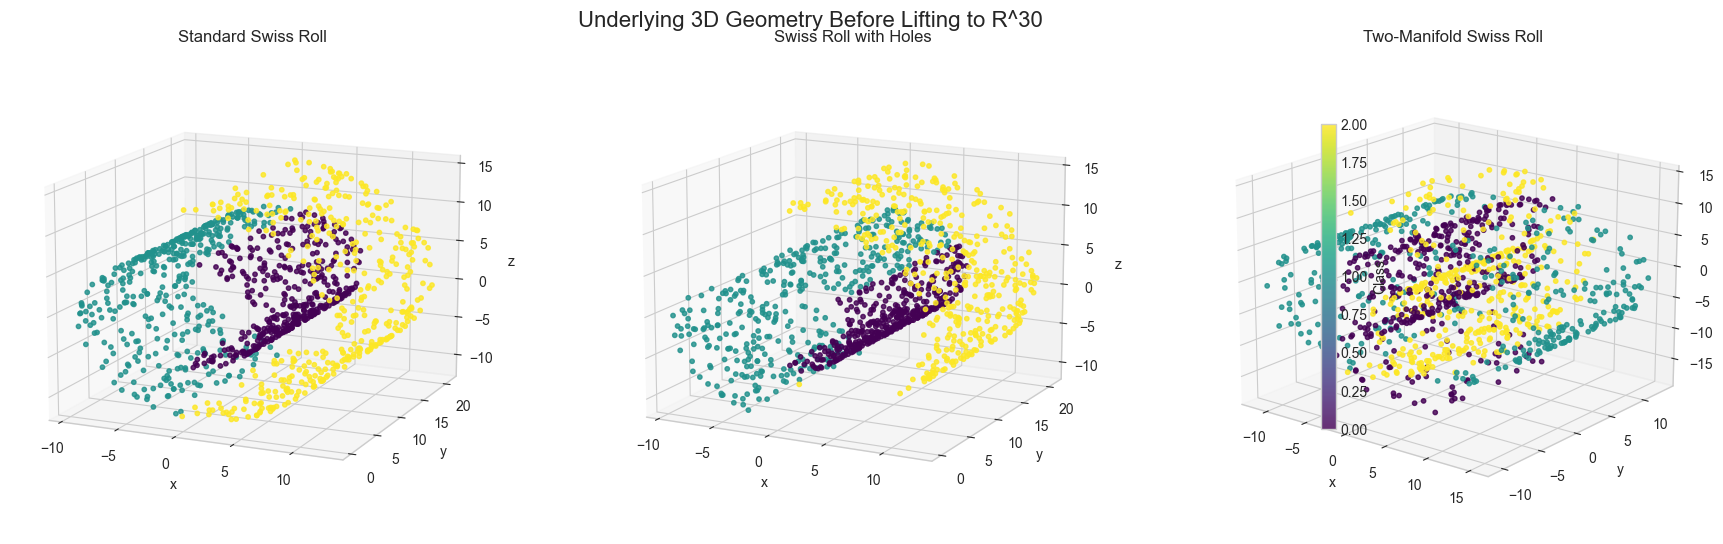

In [5]:
view_settings = {
    "standard": (14, -66),
    "holes": (14, -63),
    "two_manifold": (18, -52),
}

fig = plt.figure(figsize=(18, 5.5))
for idx, case_name in enumerate(CASE_ORDER, start=1):
    dataset = make_dataset(case_name, N_SAMPLES, noise=0.0, seed=0)
    X_base = dataset["X_base"]
    y = dataset["y"]

    ax = fig.add_subplot(1, 3, idx, projection="3d")
    scatter = ax.scatter(
        X_base[:, 0],
        X_base[:, 1],
        X_base[:, 2],
        c=y,
        cmap="viridis",
        s=10,
        alpha=0.82,
    )
    ax.view_init(*view_settings[case_name])
    ax.set_title(CASE_LABELS[case_name])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

fig.suptitle(f"Underlying 3D Geometry Before Lifting to R^{AMBIENT_DIM}", fontsize=16)
fig.colorbar(scatter, ax=fig.axes, shrink=0.72, label="Class")
fig.tight_layout()
plt.show()

The 3D plots above are shown only to explain the geometry. The actual algorithms below use the lifted $\mathbb{R}^d$ data, not these three coordinates.

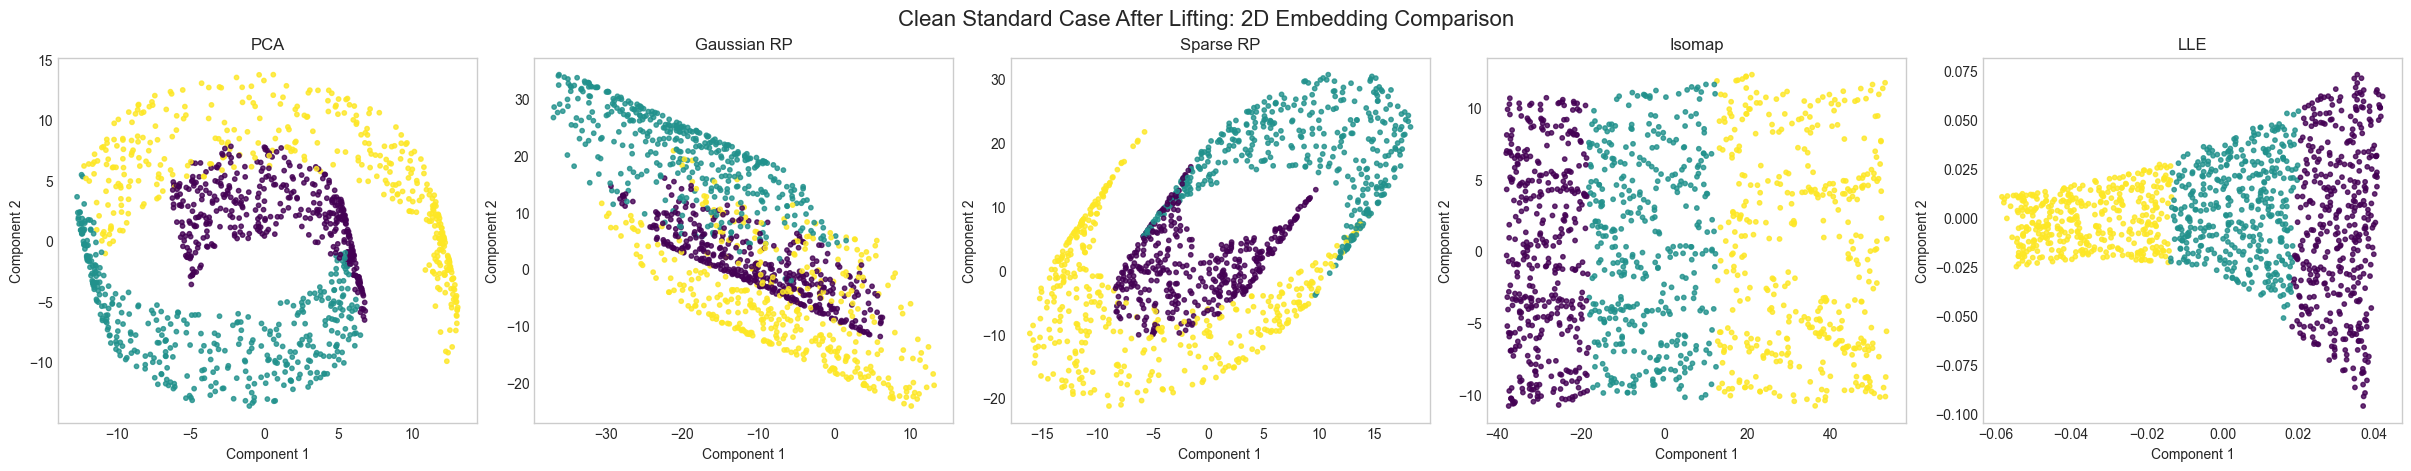

In [6]:
clean_dataset = make_dataset("standard", N_SAMPLES, noise=0.0, seed=0)
gallery_methods = build_methods(seed=0)
gallery_names = ["pca", "gaussian_rp", "sparse_rp", "isomap", "lle"]

fig, axes = plt.subplots(1, len(gallery_names), figsize=(24, 4.6), constrained_layout=True)
for ax, method_name in zip(axes, gallery_names):
    embedding = fit_transform_full(clone(gallery_methods[method_name]), clean_dataset["X_lifted"])
    ax.scatter(embedding[:, 0], embedding[:, 1], c=clean_dataset["y"], cmap="viridis", s=10, alpha=0.8)
    ax.set_title(METHOD_LABELS[method_name])
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.grid(False)

fig.suptitle("Clean Standard Case After Lifting: 2D Embedding Comparison", fontsize=16)
plt.show()

## Results

The next cells rerun the full analysis on the lifted data. Every table and figure is displayed inline so the notebook itself serves as the final report artifact.

In [7]:
results_df = pd.DataFrame(run_experiment(CASE_ORDER, NOISE_LEVELS, SEEDS))
results_df["dataset_case"] = pd.Categorical(results_df["dataset_case"], categories=CASE_ORDER, ordered=True)
results_df["method"] = pd.Categorical(results_df["method"], categories=METHOD_ORDER, ordered=True)
results_df["accuracy_pct"] = 100 * results_df["accuracy"]
results_df["neighbor_overlap_pct"] = 100 * results_df["neighbor_overlap"]
results_df["embed_time_ms"] = 1000 * results_df["embed_time_sec"]
results_df["pipeline_time_ms"] = 1000 * results_df["pipeline_time_sec"]
results_df = results_df.sort_values(["dataset_case", "method", "noise", "seed"]).reset_index(drop=True)

summary_df = (
    results_df.groupby(["dataset_case", "method", "noise"], observed=True)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        neighbor_overlap_mean=("neighbor_overlap", "mean"),
        neighbor_overlap_std=("neighbor_overlap", "std"),
        embed_time_mean=("embed_time_sec", "mean"),
        embed_time_std=("embed_time_sec", "std"),
        pipeline_time_mean=("pipeline_time_sec", "mean"),
        pipeline_time_std=("pipeline_time_sec", "std"),
    )
    .reset_index()
)

case_method_summary_df = (
    results_df.groupby(["dataset_case", "method"], observed=True)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        neighbor_overlap_mean=("neighbor_overlap", "mean"),
        embed_time_mean=("embed_time_sec", "mean"),
        pipeline_time_mean=("pipeline_time_sec", "mean"),
    )
    .reset_index()
)

print("First few experiment rows:")
display(results_df.head(12))

summary_display = summary_df.copy()
summary_display["dataset_case"] = summary_display["dataset_case"].map(CASE_LABELS)
summary_display["method"] = summary_display["method"].map(METHOD_LABELS)
summary_display["accuracy_mean"] = 100 * summary_display["accuracy_mean"]
summary_display["accuracy_std"] = 100 * summary_display["accuracy_std"]
summary_display["neighbor_overlap_mean"] = 100 * summary_display["neighbor_overlap_mean"]
summary_display["neighbor_overlap_std"] = 100 * summary_display["neighbor_overlap_std"]
summary_display["embed_time_mean"] = 1000 * summary_display["embed_time_mean"]
summary_display["embed_time_std"] = 1000 * summary_display["embed_time_std"]
summary_display["pipeline_time_mean"] = 1000 * summary_display["pipeline_time_mean"]
summary_display["pipeline_time_std"] = 1000 * summary_display["pipeline_time_std"]

print("Summary by case, method, and noise:")
display(
    summary_display.style.format(
        {
            "accuracy_mean": "{:.1f}",
            "accuracy_std": "{:.1f}",
            "neighbor_overlap_mean": "{:.1f}",
            "neighbor_overlap_std": "{:.1f}",
            "embed_time_mean": "{:.2f}",
            "embed_time_std": "{:.2f}",
            "pipeline_time_mean": "{:.2f}",
            "pipeline_time_std": "{:.2f}",
        }
    )
)

case_method_display = case_method_summary_df.copy()
case_method_display["dataset_case"] = case_method_display["dataset_case"].map(CASE_LABELS)
case_method_display["method"] = case_method_display["method"].map(METHOD_LABELS)
case_method_display["accuracy_mean"] = 100 * case_method_display["accuracy_mean"]
case_method_display["neighbor_overlap_mean"] = 100 * case_method_display["neighbor_overlap_mean"]
case_method_display["embed_time_mean"] = 1000 * case_method_display["embed_time_mean"]
case_method_display["pipeline_time_mean"] = 1000 * case_method_display["pipeline_time_mean"]

print("Average performance by case and method:")
display(
    case_method_display.style.format(
        {
            "accuracy_mean": "{:.1f}",
            "neighbor_overlap_mean": "{:.1f}",
            "embed_time_mean": "{:.2f}",
            "pipeline_time_mean": "{:.2f}",
        }
    )
)

First few experiment rows:


,dataset_case,method,noise,seed,accuracy,neighbor_overlap,embed_time_sec,pipeline_time_sec,ambient_dim,embed_dim,accuracy_pct,neighbor_overlap_pct,embed_time_ms,pipeline_time_ms
0,standard,raw_knn,0.00,0,0.986667,NaN,NaN,0.002741,30,2,98.666667,NaN,NaN,2.741042
1,standard,raw_knn,0.00,1,0.993333,NaN,NaN,0.001253,30,2,99.333333,NaN,NaN,1.253417
2,standard,raw_knn,0.00,2,0.983333,NaN,NaN,0.001344,30,2,98.333333,NaN,NaN,1.343833
3,standard,raw_knn,0.10,0,0.990000,NaN,NaN,0.001371,30,2,99.000000,NaN,NaN,1.370875
4,standard,raw_knn,0.10,1,0.993333,NaN,NaN,0.001245,30,2,99.333333,NaN,NaN,1.245291
5,standard,raw_knn,0.10,2,0.983333,NaN,NaN,0.001371,30,2,98.333333,NaN,NaN,1.371167
6,standard,raw_knn,0.20,0,0.983333,NaN,NaN,0.001368,30,2,98.333333,NaN,NaN,1.368042
7,standard,raw_knn,0.20,1,0.986667,NaN,NaN,0.001144,30,2,98.666667,NaN,NaN,1.144208
8,standard,raw_knn,0.20,2,0.976667,NaN,NaN,0.001363,30,2,97.666667,NaN,NaN,1.363458
9,standard,raw_knn,0.35,0,0.983333,NaN,NaN,0.001836,30,2,98.333333,NaN,NaN,1.835916


Summary by case, method, and noise:


,dataset_case,method,noise,accuracy_mean,accuracy_std,neighbor_overlap_mean,neighbor_overlap_std,embed_time_mean,embed_time_std,pipeline_time_mean,pipeline_time_std
0,Standard Swiss Roll,Raw k-NN,0.000000,98.8,0.5,nan,nan,nan,nan,1.78,0.83
1,Standard Swiss Roll,Raw k-NN,0.100000,98.9,0.5,nan,nan,nan,nan,1.33,0.07
2,Standard Swiss Roll,Raw k-NN,0.200000,98.2,0.5,nan,nan,nan,nan,1.29,0.13
3,Standard Swiss Roll,Raw k-NN,0.350000,98.2,0.2,nan,nan,nan,nan,1.47,0.33
4,Standard Swiss Roll,PCA,0.000000,94.2,4.6,39.3,9.4,0.54,0.16,17.55,12.14
5,Standard Swiss Roll,PCA,0.100000,94.9,5.2,38.9,9.6,0.41,0.01,10.51,0.24
6,Standard Swiss Roll,PCA,0.200000,94.2,4.6,37.7,8.8,0.40,0.01,10.53,0.09
7,Standard Swiss Roll,PCA,0.350000,93.6,4.9,35.3,8.3,0.40,0.01,10.92,0.68
8,Standard Swiss Roll,Gaussian RP,0.000000,76.8,15.7,35.3,10.2,0.38,0.09,10.91,0.90
9,Standard Swiss Roll,Gaussian RP,0.100000,75.2,17.6,34.9,9.5,0.32,0.00,10.33,0.08


Average performance by case and method:


,dataset_case,method,accuracy_mean,neighbor_overlap_mean,embed_time_mean,pipeline_time_mean
0,Standard Swiss Roll,Raw k-NN,98.5,nan,nan,1.47
1,Standard Swiss Roll,PCA,94.2,37.8,0.44,12.38
2,Standard Swiss Roll,Gaussian RP,75.1,34.2,0.34,10.63
3,Standard Swiss Roll,Sparse RP,93.5,41.4,0.50,10.86
4,Standard Swiss Roll,Isomap,98.4,82.6,142.93,387.92
5,Standard Swiss Roll,LLE,94.0,53.1,59.98,133.11
6,Swiss Roll with Holes,Raw k-NN,98.2,nan,nan,1.37
7,Swiss Roll with Holes,PCA,80.6,47.4,0.40,10.56
8,Swiss Roll with Holes,Gaussian RP,81.8,38.7,0.31,10.40
9,Swiss Roll with Holes,Sparse RP,94.6,42.9,0.51,10.63


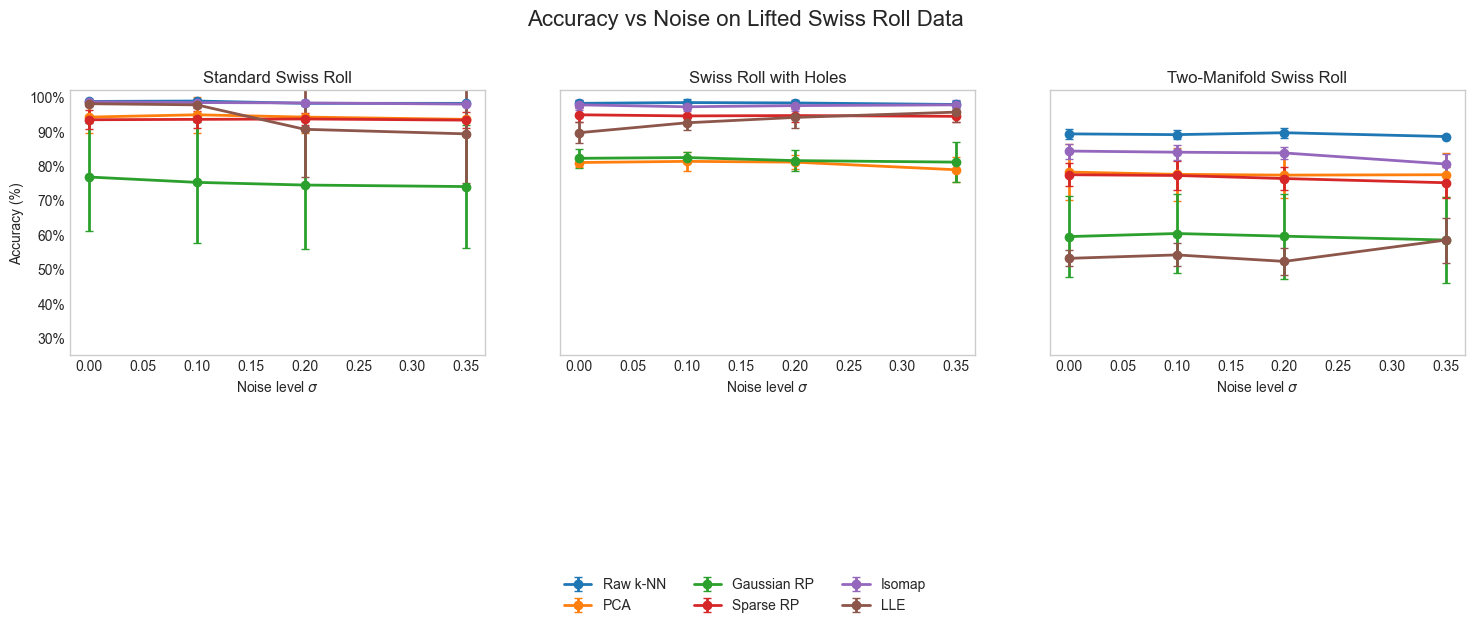

In [8]:
fig, axes = plt.subplots(1, len(CASE_ORDER), figsize=(18, 5.4), sharey=True)
fig.subplots_adjust(bottom=0.34, top=0.83, wspace=0.18)

for ax, case_name in zip(axes, CASE_ORDER):
    case_df = summary_df[summary_df["dataset_case"] == case_name]
    for method_name in METHOD_ORDER:
        method_df = case_df[case_df["method"] == method_name].sort_values("noise")
        ax.errorbar(
            method_df["noise"],
            method_df["accuracy_mean"],
            yerr=method_df["accuracy_std"].fillna(0.0),
            marker="o",
            linewidth=2,
            capsize=3,
            label=METHOD_LABELS[method_name],
        )
    ax.set_title(CASE_LABELS[case_name])
    ax.set_xlabel("Noise level $\\sigma$")
    ax.set_ylim(0.25, 1.02)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.grid(False)

axes[0].set_ylabel("Accuracy (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3, bbox_to_anchor=(0.5, -0.16), frameon=False)
fig.suptitle("Accuracy vs Noise on Lifted Swiss Roll Data", fontsize=16)
plt.show()

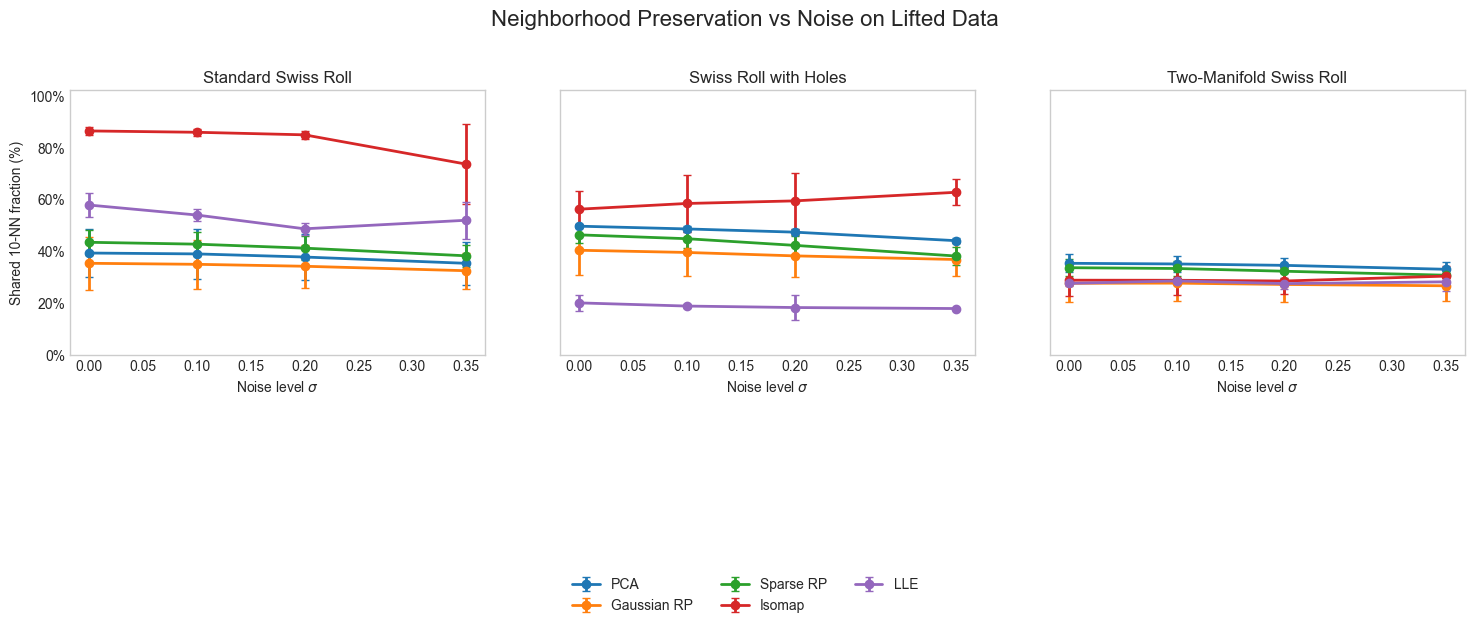

In [9]:
embed_methods = [name for name in METHOD_ORDER if name != "raw_knn"]
fig, axes = plt.subplots(1, len(CASE_ORDER), figsize=(18, 5.4), sharey=True)
fig.subplots_adjust(bottom=0.34, top=0.83, wspace=0.18)

for ax, case_name in zip(axes, CASE_ORDER):
    case_df = summary_df[summary_df["dataset_case"] == case_name]
    for method_name in embed_methods:
        method_df = case_df[case_df["method"] == method_name].sort_values("noise")
        ax.errorbar(
            method_df["noise"],
            method_df["neighbor_overlap_mean"],
            yerr=method_df["neighbor_overlap_std"].fillna(0.0),
            marker="o",
            linewidth=2,
            capsize=3,
            label=METHOD_LABELS[method_name],
        )
    ax.set_title(CASE_LABELS[case_name])
    ax.set_xlabel("Noise level $\\sigma$")
    ax.set_ylim(0.0, 1.02)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.grid(False)

axes[0].set_ylabel(f"Shared {OVERLAP_NEIGHBORS}-NN fraction (%)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3, bbox_to_anchor=(0.5, -0.16), frameon=False)
fig.suptitle("Neighborhood Preservation vs Noise on Lifted Data", fontsize=16)
plt.show()

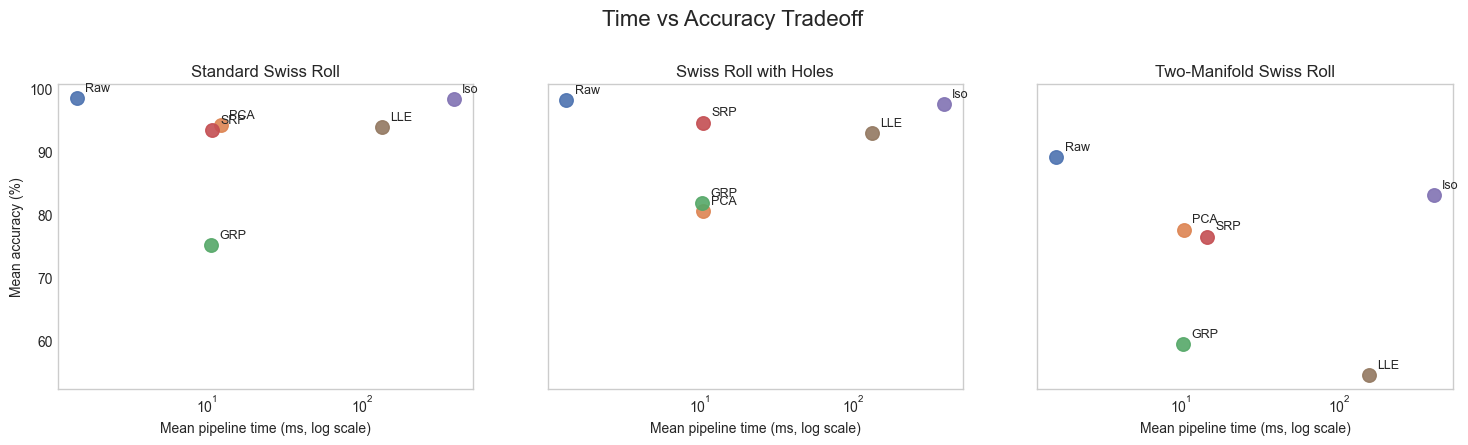

In [10]:
time_accuracy_df = (
    results_df.groupby(["dataset_case", "method"], observed=True)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        pipeline_time_mean=("pipeline_time_ms", "mean"),
    )
    .reset_index()
)

method_colors = {
    "raw_knn": "#4c72b0",
    "pca": "#dd8452",
    "gaussian_rp": "#55a868",
    "sparse_rp": "#c44e52",
    "isomap": "#8172b3",
    "lle": "#937860",
}

fig, axes = plt.subplots(1, len(CASE_ORDER), figsize=(18, 5), sharey=True)
fig.subplots_adjust(bottom=0.22, top=0.83, wspace=0.18)

for ax, case_name in zip(axes, CASE_ORDER):
    case_df = time_accuracy_df[time_accuracy_df["dataset_case"] == case_name].copy()
    ax.set_xscale("log")
    for _, row in case_df.iterrows():
        method_name = row["method"]
        ax.scatter(
            row["pipeline_time_mean"],
            100 * row["accuracy_mean"],
            s=95,
            color=method_colors[method_name],
            alpha=0.9,
        )
        ax.annotate(
            METHOD_SHORT[method_name],
            (row["pipeline_time_mean"], 100 * row["accuracy_mean"]),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=9,
        )
    ax.set_title(CASE_LABELS[case_name])
    ax.set_xlabel("Mean pipeline time (ms, log scale)")
    ax.grid(False)

axes[0].set_ylabel("Mean accuracy (%)")
fig.suptitle("Time vs Accuracy Tradeoff", fontsize=16)
plt.show()

In [11]:
runtime_table = case_method_summary_df.copy()
runtime_table["dataset_case"] = runtime_table["dataset_case"].map(CASE_LABELS)
runtime_table["method"] = runtime_table["method"].map(METHOD_LABELS)
runtime_table["accuracy_mean"] = 100 * runtime_table["accuracy_mean"]
runtime_table["pipeline_time_mean"] = 1000 * runtime_table["pipeline_time_mean"]
runtime_table = runtime_table[["dataset_case", "method", "accuracy_mean", "pipeline_time_mean"]]
runtime_table = runtime_table.rename(
    columns={
        "dataset_case": "Dataset case",
        "method": "Method",
        "accuracy_mean": "Mean accuracy (%)",
        "pipeline_time_mean": "Mean pipeline time (ms)",
    }
)

print("Runtime and accuracy summary:")
display(runtime_table.style.format({"Mean accuracy (%)": "{:.1f}", "Mean pipeline time (ms)": "{:.2f}"}))

Runtime and accuracy summary:


,Dataset case,Method,Mean accuracy (%),Mean pipeline time (ms)
0,Standard Swiss Roll,Raw k-NN,98.5,1.47
1,Standard Swiss Roll,PCA,94.2,12.38
2,Standard Swiss Roll,Gaussian RP,75.1,10.63
3,Standard Swiss Roll,Sparse RP,93.5,10.86
4,Standard Swiss Roll,Isomap,98.4,387.92
5,Standard Swiss Roll,LLE,94.0,133.11
6,Swiss Roll with Holes,Raw k-NN,98.2,1.37
7,Swiss Roll with Holes,PCA,80.6,10.56
8,Swiss Roll with Holes,Gaussian RP,81.8,10.40
9,Swiss Roll with Holes,Sparse RP,94.6,10.63


## What I Learned From the Project

A few things:

- **Time-accuracy tradeoff:** Isomap is usually one of the strongest embedding methods in accuracy and neighborhood preservation, but it is also the slowest by a wide margin. PCA and randomized projections are much faster, so they are attractive when runtime matters more than reoplicating data geometry.
- **Noisy data:** As the noise level $\sigma$ increases, both accuracy and neighborhood preservation generally decline. The geometry is still visible in the standard case, but the degradation becomes clearer in the harder extensions.
- **Holes** The holes case stresses graph construction. Missing regions make local-neighborhood assumptions less reliable, which can hurt manifold methods even when the global geometry still resembles a Swiss roll.
- **Two-manifold extension:** The two-manifold case is the hardest setting because nearby but distinct manifolds can be mixed together. Importantly, this slant distinguishes methods that preserve useful structure and methods that blur incompatible regions.
- **High-dimensional lift:** Lifting the Swiss roll into $\mathbb{R}^d$ keeps the intrinsic geometry while removing the crutch of working directly in 3D coordinates. Interestingly, the results are flipped. Compared to the analysis I presented in 3D, sparse outperforms gaussian in high dimensional data. 

Overall, manifold methods can recover nonlinear structure well, but they pay for it in runtime and sensitivity to data quality. Randomized projections are fast and sometimes competitive with the tradeoff of distorting local neighborhoods, especially in high-dimensional data.